# V45: Portfolio Transparency - Stock Selection Visibility (LQ45)

Notebook ini dimodifikasi untuk memberikan visibilitas penuh terhadap aset yang dipilih oleh algoritma Graph (MIS) selama periode simulasi.

### Fitur Baru:
1. **Selection Logger**: Mesin simulasi sekarang mencatat daftar saham yang dipilih dan bobotnya pada setiap langkah waktu.
2. **Transparency Report**: Menampilkan ringkasan saham mana yang paling sering dipilih oleh strategi AI + Graph.
3. **Excel Export (Multi-Sheet)**: Menyimpan hasil backtest harian DAN komposisi portofolio historis ke dalam file Excel agar bisa dianalisa lebih lanjut.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import fbeta_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 712 rows


In [2]:
# --- 2. AI Training (SMA Crossover Target) ---
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
X_test = features.loc[features.index.year == 2025]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
opt_t = np.linspace(0.3, 0.7, 41)[np.argmax([fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) for t in np.linspace(0.3, 0.7, 41)])]
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

In [3]:
# --- 3. Enhanced Simulation with Selection Logging ---

def get_mis_assets(returns_window, correlation_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = returns_window.columns
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    res = minimize(lambda w: -np.sum(w * mu) / np.sqrt(np.dot(w.T, np.dot(sigma, w))) if np.dot(w.T, np.dot(sigma, w)) > 0.0001 else 0,
                   [1./len(mu)]*len(mu), method='SLSQP', 
                   bounds=tuple((0, 1) for _ in range(len(mu))), 
                   constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def run_transparent_simulation(test_dates, returns, ai_probs, threshold, fee=0.0025, g_lookback=60):
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    prev_weights = {}
    risk_status = False
    buffer = 0.05
    
    # Log untuk transparansi saham
    selection_log = []
    
    for i, date in enumerate(test_dates[:-1]):
        prob = ai_probs.loc[date]
        if not risk_status and prob > (threshold + buffer): risk_status = True
            
        elif risk_status and prob < (threshold - buffer): risk_status = False
            
        if not risk_status:
            weights = {'CASH': 1.0}
            selected_stocks = []
        else:
            loc_idx = returns.index.get_loc(date)
            window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
            selected_stocks = get_mis_assets(window_rets)
            weights = optimize_markowitz(window_rets[selected_stocks])
        
        # Record selection
        selection_log.append({
            'Date': date,
            'Risk_Status': 'Risk-On' if risk_status else 'Risk-Off',
            'AI_Prob': prob,
            'Num_Assets': len(selected_stocks),
            'Assets': ", ".join(selected_stocks) if selected_stocks else "CASH"
        })
        
        all_assets = set(list(weights.keys()) + list(prev_weights.keys()))
        turnover = sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_assets)
        val -= val * turnover * fee
        
        next_date = test_dates[i+1]
        day_ret = 0 if 'CASH' in weights else sum(w * returns.loc[next_date, a] for a, w in weights.items())
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        prev_weights = weights
        
    return pd.DataFrame({'Portfolio_Value': history}, index=dates), pd.DataFrame(selection_log)

Top 10 Most Frequently Selected Stocks in Risk-On Periods:
AMRT.JK    100
ICBP.JK     96
BRPT.JK     90
AKRA.JK     90
ADRO.JK     89
MIKA.JK     89
MEDC.JK     88
GOTO.JK     87
EXCL.JK     85
PGAS.JK     83
Name: count, dtype: int64


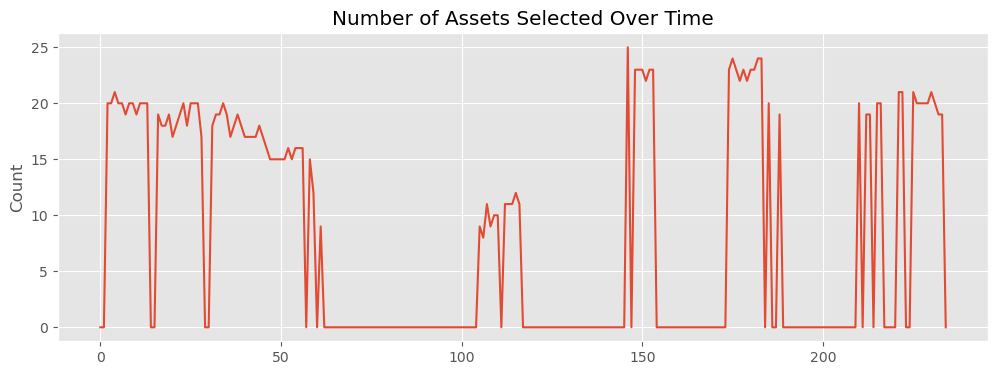

In [4]:
# --- 4. Run Simulation & Show Transparency ---
test_dates = test_probs.index
val_history, selection_history = run_transparent_simulation(test_dates, returns, test_probs, opt_t)

print("Top 10 Most Frequently Selected Stocks in Risk-On Periods:")
# Pisahkan string Assets kembali menjadi list untuk dihitung
all_selected = []
for assets in selection_history[selection_history['Risk_Status'] == 'Risk-On']['Assets']:
    all_selected.extend(assets.split(", "))

freq = pd.Series(all_selected).value_counts()
print(freq.head(10))

# Analysis of Selection
plt.figure(figsize=(12, 4))
selection_history['Num_Assets'].plot(title="Number of Assets Selected Over Time")
plt.ylabel("Count")
plt.show()

In [5]:
# --- 5. Export Multi-Sheet Excel ---
export_file = 'v20_portfolio_with_visibility_2025.xlsx'
with pd.ExcelWriter(export_file) as writer:
    val_history.to_excel(writer, sheet_name='Daily_Portfolio_Value')
    selection_history.to_excel(writer, sheet_name='Asset_Selection_Log', index=False)
    freq.to_frame(name='Frequency').to_excel(writer, sheet_name='Stock_Frequency_Report')

print(f"✓ Transparency report exported to {export_file}")

✓ Transparency report exported to v20_portfolio_with_visibility_2025.xlsx
